In [1]:
import pandas as pd

ModuleNotFoundError: No module named 'pandas'

In [1]:
import pandas as pd

ModuleNotFoundError: No module named 'pandas'

In [2]:
import pandas as pd

print(pd.__version__)

3.0.3


In [3]:
df = pd.read_csv("../data/raw/ad_spend.csv")

In [4]:
df.head()

,date,channel,campaign,spend
0,1/1/2025,Google Ads,Competitor Search,2185.43
1,1/1/2025,Facebook Ads,Winter Sale,4778.21
2,1/1/2025,TikTok Ads,Influencer Push,3793.97
3,1/1/2025,Organic Search,Organic Landing,0.00
4,1/2/2025,Google Ads,Brand Search,3193.96


In [5]:
df.head(10)

,date,channel,campaign,spend
0,1/1/2025,Google Ads,Competitor Search,2185.43
1,1/1/2025,Facebook Ads,Winter Sale,4778.21
2,1/1/2025,TikTok Ads,Influencer Push,3793.97
3,1/1/2025,Organic Search,Organic Landing,0.00
4,1/2/2025,Google Ads,Brand Search,3193.96
5,1/2/2025,Facebook Ads,Winter Sale,1202.08
6,1/2/2025,TikTok Ads,Influencer Push,1201.98
7,1/2/2025,Organic Search,SEO Blog,0.00
8,1/3/2025,Google Ads,Competitor Search,761.38
9,1/3/2025,Facebook Ads,Lookalike Audience,4397.79


In [ ]:
#dataset dimensions
print("Shape:", df.shape)

Shape: (724, 4)


In [7]:
#display column names
print("Columns:")
print(df.columns)

Columns:
Index(['date', 'channel', 'campaign', 'spend'], dtype='str')


In [ ]:
#dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 724 entries, 0 to 723
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   date      724 non-null    str    
 1   channel   724 non-null    str    
 2   campaign  724 non-null    str    
 3   spend     724 non-null    float64
dtypes: float64(1), str(3)
memory usage: 22.8 KB


In [9]:
#missing values
df.isnull().sum()

date        0
channel     0
campaign    0
spend       0
dtype: int64

In [10]:
#descriptive records
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [11]:
#summary statistics
df.describe()

,spend
count,724.000000
mean,2086.547196
std,1680.412533
min,0.000000
25%,392.085000
50%,1971.645000
75%,3610.297500
max,4998.730000


In [12]:
#categorical columns
print("Unique Channels:")
print(df["channel"].unique())

print("\nNumber of Channels:", df["channel"].nunique())

Unique Channels:
<StringArray>
['Google Ads', 'Facebook Ads', 'TikTok Ads', 'Organic Search']
Length: 4, dtype: str

Number of Channels: 4


In [13]:
#campaign 
print("Unique Campaigns:")
print(df["campaign"].unique())

print("\nNumber of Campaigns:", df["campaign"].nunique())

Unique Campaigns:
<StringArray>
[ 'Competitor Search',        'Winter Sale',    'Influencer Push',
    'Organic Landing',       'Brand Search',           'SEO Blog',
 'Lookalike Audience',       'UGC Campaign',        'Retargeting',
     'Generic Search',    'Awareness Blast']
Length: 11, dtype: str

Number of Campaigns: 11


In [14]:
#record per channel
df["channel"].value_counts()

channel
Google Ads        181
Facebook Ads      181
TikTok Ads        181
Organic Search    181
Name: count, dtype: int64

In [15]:
#record per campaign
df["campaign"].value_counts()

campaign
SEO Blog              97
Organic Landing       84
Winter Sale           68
Competitor Search     66
Brand Search          63
Retargeting           63
Awareness Blast       61
Influencer Push       60
UGC Campaign          60
Generic Search        52
Lookalike Audience    50
Name: count, dtype: int64

In [16]:
#convert date column to datetime format
df["date"] = pd.to_datetime(df["date"])

In [17]:
#verify 
df.dtypes

date        datetime64[us]
channel                str
campaign               str
spend              float64
dtype: object

In [18]:
#date range
print("Start Date:", df["date"].min())
print("End Date:", df["date"].max())

Start Date: 2025-01-01 00:00:00
End Date: 2025-06-30 00:00:00


In [19]:
#save to cleaned dataset folder
df.to_csv("../data/cleaned/ad_spend_cleaned.csv", index=False)


In [20]:
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [21]:
#visualization 
import matplotlib.pyplot as plt

In [22]:
#total spend per channel
total_spend_per_channel = df.groupby("channel")["spend"].sum()

In [23]:
plt.figure(figsize=(8,5))
channel_spend.plot(kind="bar")

NameError: name 'channel_spend' is not defined

<Figure size 800x500 with 0 Axes>

In [24]:
plt.figure(figsize=(8,5))
channel_spend.plot(kind="bar")

plt.title("Total Spend by Channel")
plt.xlabel("Channel")
plt.ylabel("Total Spend")

plt.xticks(rotation=0)
plt.show()

NameError: name 'channel_spend' is not defined

<Figure size 800x500 with 0 Axes>

In [25]:
channel_spend = df.groupby("channel")["spend"].sum()

print(channel_spend)

channel
Facebook Ads      517986.43
Google Ads        507942.92
Organic Search         0.00
TikTok Ads        484730.82
Name: spend, dtype: float64


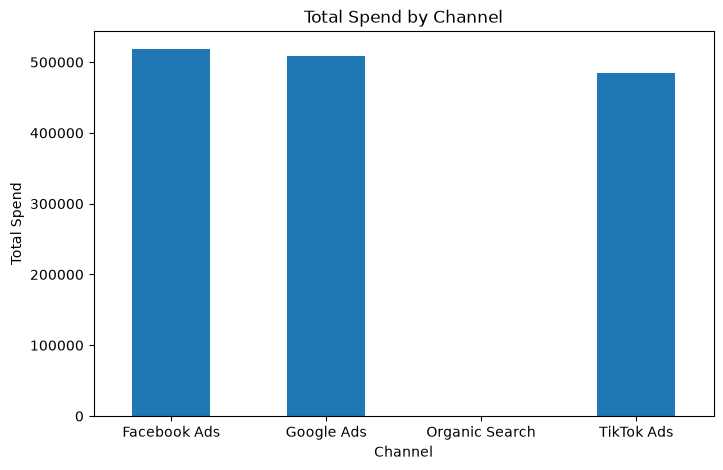

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
channel_spend.plot(kind="bar")

plt.title("Total Spend by Channel")
plt.xlabel("Channel")
plt.ylabel("Total Spend")

plt.xticks(rotation=0)
plt.show()

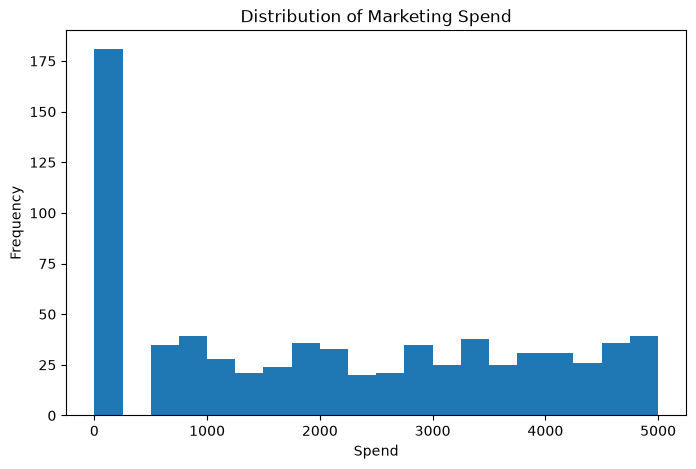

In [27]:
#spend distribution
plt.figure(figsize=(8,5))

plt.hist(df["spend"], bins=20)

plt.title("Distribution of Marketing Spend")
plt.xlabel("Spend")
plt.ylabel("Frequency")

plt.show()

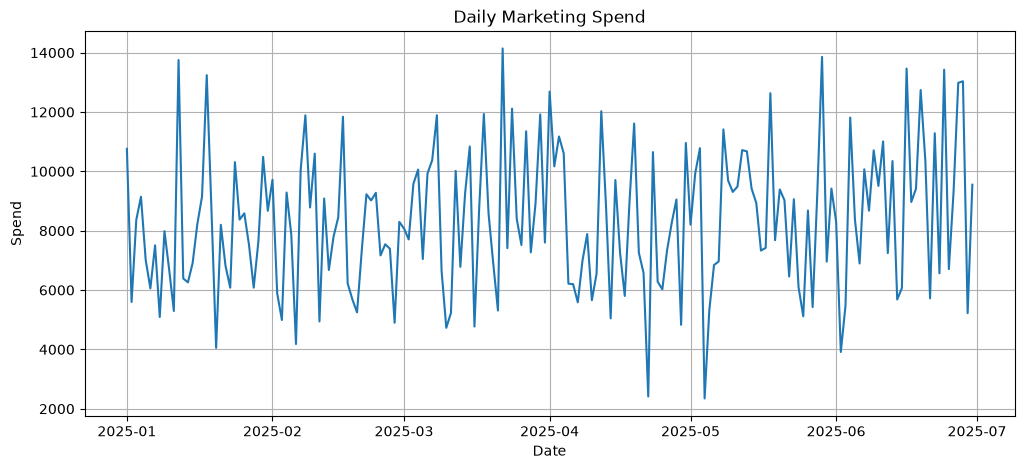

In [28]:
#daily spend trend
daily_spend = df.groupby("date")["spend"].sum()

plt.figure(figsize=(12,5))

plt.plot(daily_spend.index, daily_spend.values)

plt.title("Daily Marketing Spend")
plt.xlabel("Date")
plt.ylabel("Spend")

plt.grid(True)

plt.show()

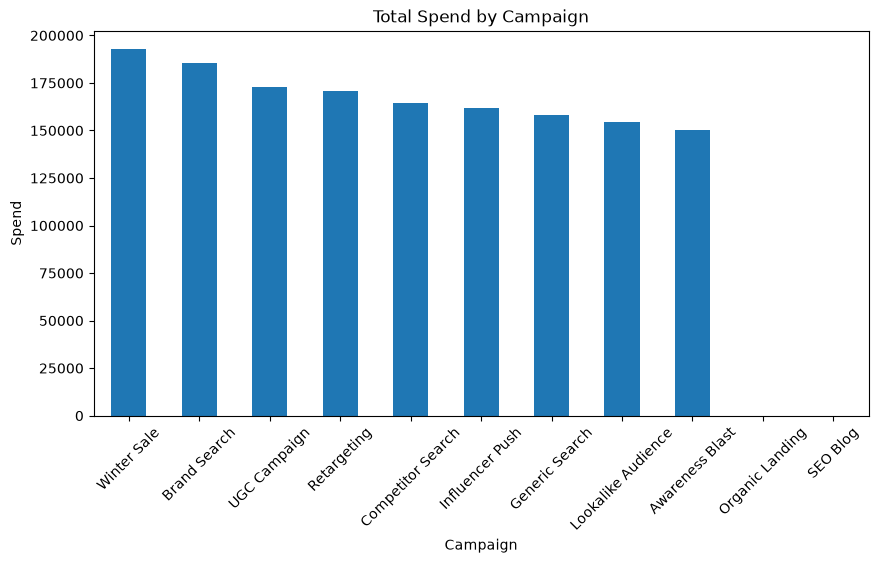

In [29]:
#top campaigns by spend
campaign_spend = df.groupby("campaign")["spend"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))

campaign_spend.plot(kind="bar")

plt.title("Total Spend by Campaign")
plt.xlabel("Campaign")
plt.ylabel("Spend")

plt.xticks(rotation=45)

plt.show()

In [ ]:
# Conclusion

#- Dataset contains **724 marketing records** across four channels.
#- No missing values or duplicate records were found.
#- The date column was converted to datetime format.
#- The dataset covers the period from **1 January 2025 to 30 June 2025**.
#- The cleaned dataset was saved for further analysis.
#- Initial visualizations show marketing spend distribution by channel, campaign, and over time.
